# Data Preparation

In [173]:
# Import necessary libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

# Load the dataset
file_path = "games_c5.csv"
df = pd.read_csv(file_path)

# Explore the dataset
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8158 entries, 0 to 8157
Data columns (total 83 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   AppID                       8158 non-null   int64  
 1   QueryName                   8158 non-null   object 
 2   DeveloperCount              8158 non-null   int64  
 3   Unnamed: 11                 0 non-null      float64
 4   RecommendationCount         8158 non-null   int64  
 5   PublisherCount              8158 non-null   int64  
 6   SteamSpyOwners              8158 non-null   int64  
 7   SteamSpyPlayersEstimate     8158 non-null   int64  
 8   Unnamed: 20                 0 non-null      float64
 9   Unnamed: 21                 0 non-null      float64
 10  Unnamed: 23                 0 non-null      float64
 11  PurchaseAvail               8158 non-null   bool   
 12  Unnamed: 25                 0 non-null      float64
 13  PlatformWindows             8158 

In [174]:
df= df.drop(columns=[
    'Unnamed: 11', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 23', 'Unnamed: 25',
    'Developers', 'developers',  # Developer related columns
    'AppID', 'QueryName',
    'publishers',  # Publisher related columns
    'PriceCurrency',  # Price related
    'Recommendations',  # Reviews and ratings
    'DLC count',  # Redundant DLC count
    'Categories',  # Redundant category
    'Single-player',  # Redundant category
    'GenreIsAction', 'GenreIsAdventure', 'GenreIsCasual',  # Specific genres
    'PlatformWindows', 'ShortDescrip', 'DetailedDescrip',
    'Release date', 'Windows', 'Genres', 'Day',
    # 'Cross-Platform', 'Multiplayer',
    'Online PvP', 'PvP', 'VR Supported', 'about_the_game', 'packages', 'categories',
    'genres', 'tags', 'pct_pos_total', 'pct_pos_recent', 'num_reviews_recent', 'CustomRating',
    'Metacritic score',
    'num_reviews_total',
    'SteamSpyPlayersEstimate'
])

## Zero replacement

In [175]:
zero_columns = ['Achievements', 'Price', 'dlc_count', 'VR Support','Multi-player'] + list(df.iloc[:, 10:31].columns)

df[zero_columns] = df[zero_columns].fillna(0)

## Not found

In [176]:
df['Publishers'] = df['Publishers'].fillna('Not Found')

## Most Frequent

In [177]:
import numpy as np
from datetime import datetime

# Assuming df_games is the dataset, current year for calculating year difference
current_year = datetime.now().year

# Fill 'Year' with the most frequent year and calculate (current_year - Year)
most_frequent_year = df['Year'].mode()[0]
df['Year'] = df['Year'].fillna(most_frequent_year)
df['YearDifference'] = current_year - df['Year']

# Fill 'Month' with the most frequent month and create sin and cos transformations
most_frequent_month = df['Month'].mode()[0]
df['Month'] = df['Month'].fillna(most_frequent_month)

# Creating sin and cos transformations for cyclical month representation
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

df.drop(columns=['Year', 'Month'], inplace=True)

## Average

In [178]:
imp_mean = SimpleImputer(strategy='mean')
mean_feats = ['age_ranking', 'rating', 'ReviewScore', 'avg_playtime']

df[mean_feats] = imp_mean.fit_transform(df[mean_feats])

## Median

In [179]:
imp_median = SimpleImputer(strategy='median')

median_feats = ['TotalReviews', 'positive', 'negative']

df[median_feats] = imp_median.fit_transform(df[median_feats])

## Balance (positive x negative)

In [180]:
df['balance_pos_neg'] = df['positive'] - df['negative']

df.drop(columns=['positive', 'negative'], inplace=True)

## One Hot Encoder

In [181]:
enc_bool = OneHotEncoder(handle_unknown='ignore', drop='if_binary')

enc_bool.fit(df[['PurchaseAvail', 'CategorySinglePlayer']])

encoded_df = pd.DataFrame(enc_bool.transform(
    df[['PurchaseAvail', 'CategorySinglePlayer']]).toarray(),
    columns=enc_bool.get_feature_names_out(['PurchaseAvail', 'CategorySinglePlayer'])
)

encoded_df.index = df.index

df = df.drop(['PurchaseAvail', 'CategorySinglePlayer'], axis=1)
df = pd.concat([df, encoded_df], axis=1)
df.rename(columns={'PurchaseAvail_True':'PurchaseAvail', 'CategorySinglePlayer_True':'CategorySinglePlayer'},
                inplace=True)

In [182]:
dd = pd.read_csv('../data/dd.csv')

def calculate_points(row):
    points = 0
    AAA_List_P = dd['Publishers'][0:47].to_list()
    AA_List_P = dd['Publishers'][47:300].to_list()
    indie_List_P = dd['Publishers'][300:].to_list()

    # ckeck if the game's publisher is the lists
    if row['Publishers']  in AAA_List_P:
        points += 500
    elif row['Publishers'] in AA_List_P:
        points += 50
    else:
        points += 1
    # Price points
    if row['Price'] >= 30.00:
        points += 5
    elif 20 <= row['Price'] < 30.00:
        points += 3
    else:
        points += 1
    # TotalReviews points
    if row['TotalReviews'] > 30000:
        points += 5
    elif 5000 <= row['TotalReviews'] <= 30000:
        points += 3
    else:
        points += 1
    # DeveloperCount points
    if row['DeveloperCount'] >= 2:
        points += 3
    elif row['DeveloperCount'] == 1:
        points += 2
    else:
        points += 1
    # Achievements points
    if row['Achievements'] > 20:
        points += 3
    else:
        points += 1
    # avg_playtime points
    if row['avg_playtime'] > 1000:
        points += 3
    elif 100 <= row['avg_playtime'] <= 1000:
        points += 2
    else:
        points += 1
    return points
# Apply the function to calculate points for each game
df['TotalPoints'] = df.apply(calculate_points, axis=1)
# Define thresholds for BudgetCategory based on points
def categorize_by_points(row):
    if row['TotalPoints'] >= 200:
        return 'AAA'
    elif 12 <= row['TotalPoints'] < 199:
        return 'AA'
    else:
        return 'Indie'
# Apply the categorization
df['BudgetCategory'] = df.apply(categorize_by_points, axis=1)

# delete Publishers
df.drop(columns='Publishers', inplace=True)


In [183]:
df = pd.get_dummies(df, columns=['BudgetCategory'], prefix='Budget')


In [184]:
# Save the cleaned dataset for further processing
df.to_csv("cleaned_c5.csv", index=False)

print("Initial data preparation complete.")

Initial data preparation complete.


In [185]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8158 entries, 0 to 8157
Data columns (total 46 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   DeveloperCount              8158 non-null   int64  
 1   RecommendationCount         8158 non-null   int64  
 2   PublisherCount              8158 non-null   int64  
 3   SteamSpyOwners              8158 non-null   int64  
 4   PCMinReqsText               8146 non-null   object 
 5   Achievements                8158 non-null   float64
 6   Adventure                   8158 non-null   float64
 7   Casual                      8158 non-null   float64
 8   Indie                       8158 non-null   float64
 9   RPG                         8158 non-null   float64
 10  Free To Play                8158 non-null   float64
 11  Action                      8158 non-null   float64
 12  Strategy                    8158 non-null   float64
 13  Simulation                  8158 

## PC Requirements Extraction


In [186]:
# Function to extract PC requirements from the text
def extract_pc_requirements(text):
    if pd.isnull(text):
        return {"cpu_ghz": 0, "ram_gb": 0, "gpu": "Unknown", "storage_gb": 0}

    # Extract CPU GHz
    cpu_match = re.search(r"(\d+(\.\d+)?)\s*GHz", text)
    cpu_ghz = float(cpu_match.group(1)) if cpu_match else 0

    # Extract RAM in GB
    ram_match = re.search(r"(\d+)\s*GB\s*RAM", text)
    ram_gb = int(ram_match.group(1)) if ram_match else 0

    # Extract GPU model
    gpu_match = re.search(r"(GTX|RTX|Radeon)\s*\d+", text)
    gpu = gpu_match.group(0) if gpu_match else "Unknown"

    # Extract storage in GB
    storage_match = re.search(r"(\d+)\s*GB", text)
    storage_gb = int(storage_match.group(1)) if storage_match else 0

    return {"cpu_ghz": cpu_ghz, "ram_gb": ram_gb, "gpu": gpu, "storage_gb": storage_gb}

# Apply the function to the PCMinReqsText column
pc_features = df["PCMinReqsText"].apply(extract_pc_requirements)
pc_features_df = pd.DataFrame(pc_features.tolist())

# Add the extracted features to the main dataframe
df = pd.concat([df, pc_features_df], axis=1)

# Drop the original `PCMinReqsText` column
df = df.drop(columns=["PCMinReqsText"], errors="ignore")

# Save the updated dataset
df.to_csv("cleaned_with_pc_features.csv", index=False)

print("PC requirements extraction complete.")
print(df.info())


PC requirements extraction complete.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8158 entries, 0 to 8157
Data columns (total 49 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   DeveloperCount              8158 non-null   int64  
 1   RecommendationCount         8158 non-null   int64  
 2   PublisherCount              8158 non-null   int64  
 3   SteamSpyOwners              8158 non-null   int64  
 4   Achievements                8158 non-null   float64
 5   Adventure                   8158 non-null   float64
 6   Casual                      8158 non-null   float64
 7   Indie                       8158 non-null   float64
 8   RPG                         8158 non-null   float64
 9   Free To Play                8158 non-null   float64
 10  Action                      8158 non-null   float64
 11  Strategy                    8158 non-null   float64
 12  Simulation                  8158 non-null   float64
 

In [187]:
df.drop(columns='gpu', inplace=True)


In [188]:
# Median imputation for columns with zeros
columns_to_impute = ['cpu_ghz', 'ram_gb', 'storage_gb']

for col in columns_to_impute:
    # Calculate the median excluding zero values
    median_value = df[col][df[col] > 0].median()
    # Replace zero values with the median
    df[col] = df[col].replace(0, median_value)

# Check the result
print(df[columns_to_impute].describe())


           cpu_ghz        ram_gb   storage_gb
count  8158.000000   8158.000000  8158.000000
mean      2.418003      6.154572     2.983697
std       7.530255    332.324192    30.378699
min       0.500000      1.000000     1.000000
25%       2.000000      2.000000     2.000000
50%       2.000000      2.000000     2.000000
75%       2.000000      2.000000     2.000000
max     280.000000  30001.000000  2490.000000


In [189]:
df['cpu_ghz'] = df['cpu_ghz'].clip(upper=5)  # Cap at 5 GHz
df['ram_gb'] = df['ram_gb'].clip(upper=64)   # Cap at 64 GB
df['storage_gb'] = df['storage_gb'].clip(upper=500)  # Cap at 500 GB

# Check summary statistics after capping
print(df[['cpu_ghz', 'ram_gb', 'storage_gb']].describe())

           cpu_ghz       ram_gb   storage_gb
count  8158.000000  8158.000000  8158.000000
mean      1.995473     2.265261     2.732410
std       0.535232     2.010881    13.689811
min       0.500000     1.000000     1.000000
25%       2.000000     2.000000     2.000000
50%       2.000000     2.000000     2.000000
75%       2.000000     2.000000     2.000000
max       5.000000    64.000000   500.000000


In [190]:
# === Price Categorization ===
print("Categorizing Price...")
# Define price thresholds
def categorize_price(price):
    if price == 0:
        return "Free"
    elif price < 10:
        return "Low"
    elif price < 30:
        return "Medium"
    else:
        return "High"

# Apply the categorization
df["PriceCategory"] = df["Price"].apply(categorize_price)

# One-hot encode the price categories
price_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
price_encoded = price_encoder.fit_transform(df[["PriceCategory"]])

# Add the encoded price categories to the DataFrame
price_df = pd.DataFrame(price_encoded, columns=price_encoder.get_feature_names_out(["PriceCategory"]))
df = pd.concat([df, price_df], axis=1)

# Drop the original PriceCategory column
df.drop(columns=["PriceCategory"], inplace=True)


# === Developer and Publisher Impact ===
print("Calculating Developer and Publisher Impact...")
# Define thresholds for high-quality developers and publishers
df["HighQualityDeveloper"] = df["DeveloperCount"].apply(lambda x: 1 if x > 2 else 0)
df["HighQualityPublisher"] = df["PublisherCount"].apply(lambda x: 1 if x > 2 else 0)


# Drop DeveloperCount and PublisherCount if necessary
df.drop(columns=["DeveloperCount", "PublisherCount"], inplace=True)

# Save the final processed DataFrame
df.to_csv("processed_features.csv", index=False)

print("Feature engineering complete.")
print(df.info())


Categorizing Price...
Calculating Developer and Publisher Impact...
Feature engineering complete.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8158 entries, 0 to 8157
Data columns (total 51 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   RecommendationCount         8158 non-null   int64  
 1   SteamSpyOwners              8158 non-null   int64  
 2   Achievements                8158 non-null   float64
 3   Adventure                   8158 non-null   float64
 4   Casual                      8158 non-null   float64
 5   Indie                       8158 non-null   float64
 6   RPG                         8158 non-null   float64
 7   Free To Play                8158 non-null   float64
 8   Action                      8158 non-null   float64
 9   Strategy                    8158 non-null   float64
 10  Simulation                  8158 non-null   float64
 11  Racing                      8158 non-null   float

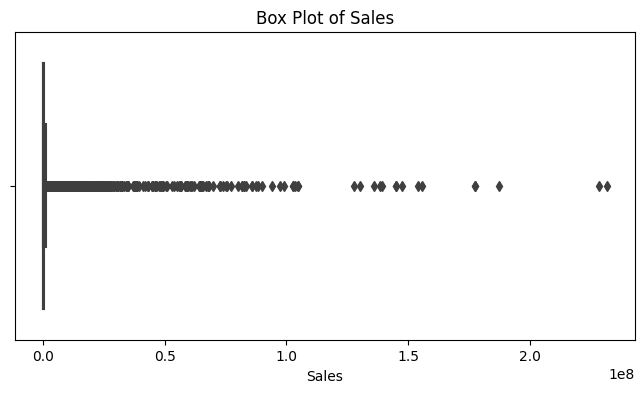

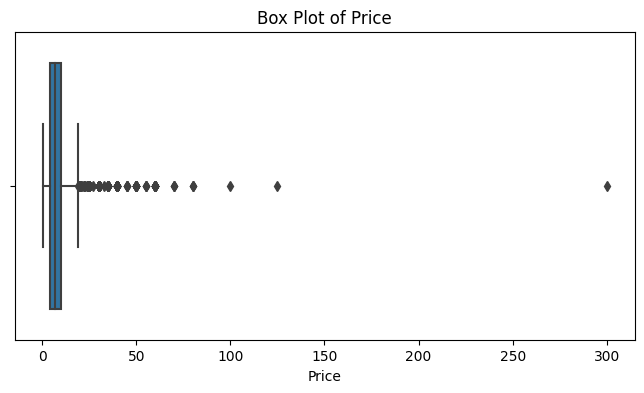

              Sales        Price
count  8.158000e+03  8158.000000
mean   2.116285e+06     9.378571
std    1.026551e+07     9.069192
min    2.611700e+02     0.490000
25%    2.149848e+04     3.990000
50%    1.003396e+05     6.990000
75%    5.205434e+05     9.990000
max    2.315900e+08   299.900000


In [191]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Visualize distribution of key features
key_features = ['Sales', 'Price']

for feature in key_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()

# Describe the key features
print(df[key_features].describe())


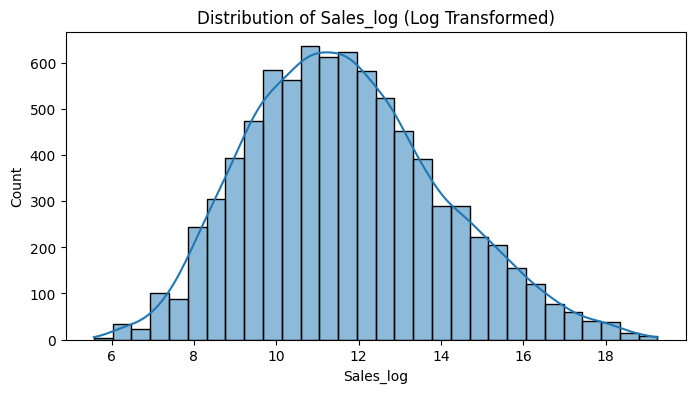

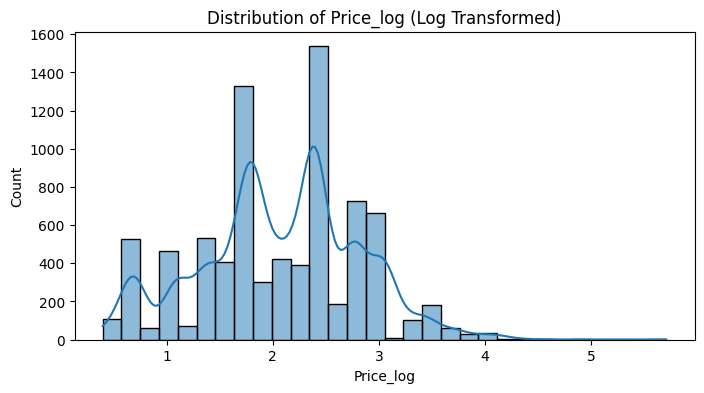

In [192]:
# Apply log transformation (add 1 to avoid log(0))
df['Sales_log'] = np.log1p(df['Sales'])
df['Price_log'] = np.log1p(df['Price'])

# Check distributions after transformation
for feature in ['Sales_log', 'Price_log']:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature], bins=30, kde=True)
    plt.title(f'Distribution of {feature} (Log Transformed)')
    plt.show()


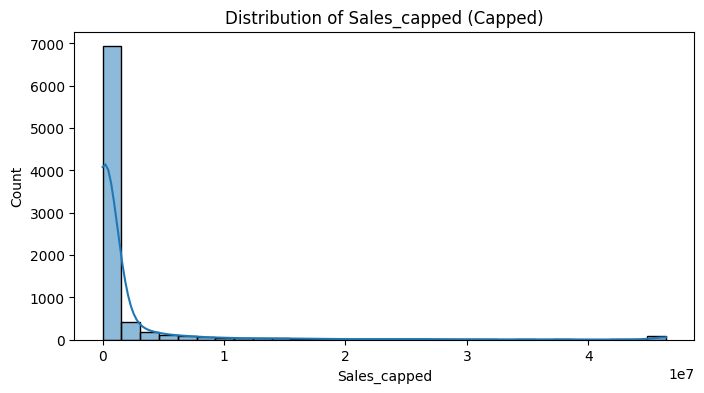

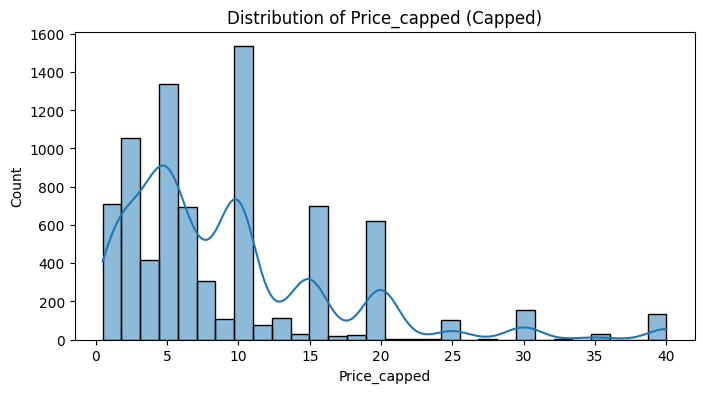

In [193]:
# Cap extreme values at the 99th percentile
sales_cap = df['Sales'].quantile(0.99)
price_cap = df['Price'].quantile(0.99)

df['Sales_capped'] = df['Sales'].clip(upper=sales_cap)
df['Price_capped'] = df['Price'].clip(upper=price_cap)

# Check distributions after capping
for feature in ['Sales_capped', 'Price_capped']:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature], bins=30, kde=True)
    plt.title(f'Distribution of {feature} (Capped)')
    plt.show()


In [194]:
import pandas as pd

# Load the processed dataset
file_path = "processed_features.csv"
df = pd.read_csv(file_path)

# Apply log transformation
df["Sales_log"] = df["Sales"].apply(lambda x: np.log(x + 1))
df["Price_log"] = df["Price"].apply(lambda x: np.log(x + 1))

# Apply capping
df["Sales_capped"] = df["Sales"].clip(upper=4e6)  # Cap sales at 4M
df["Price_capped"] = df["Price"].clip(upper=40)   # Cap price at $40

# Save the updated dataset for retraining
updated_dataset = "processed_features_updated.csv"
df.to_csv(updated_dataset, index=False)

# Display summary of the updated dataset
summary_stats = df[["Sales_log", "Price_log", "Sales_capped", "Price_capped"]].describe()
# Display summary statistics for the updated dataset
print("Summary Statistics of Updated Features:")
print(summary_stats)

updated_dataset


Summary Statistics of Updated Features:
         Sales_log    Price_log  Sales_capped  Price_capped
count  8158.000000  8158.000000  8.158000e+03   8158.000000
mean     11.686561     2.067928  6.692424e+05      9.192347
std       2.349929     0.742884  1.206877e+06      7.643192
min       5.568993     0.398776  2.611700e+02      0.490000
25%       9.975784     1.607436  2.149848e+04      3.990000
50%      11.516325     2.078191  1.003396e+05      6.990000
75%      13.162630     2.396986  5.205434e+05      9.990000
max      19.260479     5.706778  4.000000e+06     40.000000


'processed_features_updated.csv'

## scaling

rob_feat = [#'DeveloperCount',
    'RecommendationCount',
    #'PublisherCount',
    # 'SteamSpyPlayersEstimate',
    'Achievements',
    'Price',
    'dlc_count',
    'balance_pos_neg',
    'TotalReviews',
    'Sales',
    'avg_playtime']

std_feat = ['rating', 'ReviewScore']

rob = RobustScaler()

std = StandardScaler()

df[rob_feat] = rob.fit_transform(df[rob_feat])
df[std_feat] = std.fit_transform(df[std_feat])

# Save the final processed DataFrame
df.to_csv("processed_features.csv", index=False)